In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Import libraries

In [2]:
# MFCC |  delta-delta | delta | With-residuals - Pipeline changes (split first before augmentation)

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, random_split

import librosa

import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F

import librosa
import librosa.display

from tqdm import tqdm
from typing import List
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from scipy.io.wavfile import write
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device # Insure a GPU

device(type='cuda')

In [5]:
# Important variables

# All file paths
ROOT_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"
OUT_PATH = "/kaggle/working/"
CSV_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"
PATIENT_INFO_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt"

# Audio processing parameters
SAMPLING_RATE = 16000
MAX_LEN = 4.5
WINDOW_SIZE = int(SAMPLING_RATE * MAX_LEN)
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128

# Hyperparameters 
BATCH_SIZE = 128
LEARNING_RATE = 0.0001
EPOCH = 100

ALPHA=0.85
GEMMA=2.0

In [ ]:
patient_disease_class_df = pd.read_csv(
    CSV_PATH,
    names=[
        'patient_number', 
        'disease_class'
    ]
)

# Create a dictionary which contains patient's number and their disease
patient_disease_class = {}

for patient_num, class_ in zip(
    patient_disease_class_df['patient_number'],
    patient_disease_class_df['disease_class']
):
    patient_disease_class[patient_num] = class_

In [7]:
WORKING_DIR = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"
df = pd.read_csv(
    WORKING_DIR,
    names=['patient_id', 'disease_class']
)

In [8]:
cls_label = {
    'COPD': 0,
    'Healthy': 1,
    'Pneumonia': 2
}

In [9]:
def pad_waveform(
    waveform: torch.tensor, 
    target_length: (int) = WINDOW_SIZE
):
    """
    Pad the waveform to window_size.

    Arg(s):
        waveform (Tensor):  Waveform tensor of size [1, n]
        target_length (int): Target length for pad
    Return:
        padded_waveform (Tensor): Padded waveform of size [1, target_length]
    """
    current_length = waveform.shape[1]

    if current_length < target_length:
        padding = target_length - current_length

        waveform = torch.nn.functional.pad(
            waveform,
            (0, padding)
        )

    else:
        waveform = waveform[:, :target_length]

    return waveform

In [10]:
def augment_data(waveform):
    noise_factor = 0.0001
    white_noise = torch.randn_like(waveform) * noise_factor
    waveform_white_noise = waveform + white_noise

    shifted_audio = torch.roll(waveform, shifts=10000, dims=1)
    
    # 3. Volume Perturbation (Safe alternative to Pitch Shifting)
    # Randomly scale the volume by 10% to simulate different microphone distances
    gain = torch.empty(1).uniform_(0.9, 1.1).item()
    volume_audio = waveform * gain

    return [
        waveform_white_noise,
        shifted_audio,
        volume_audio
    ]

In [11]:
def get_label(
    crackles: str = 0, 
    wheezes: str = 1
) -> int:
    """
    A function used to get class of crackles and wheezes combination.

    Args:
        crackles (str): Crackles sound (1=present, 0=non_present)
        wheezes (str): Wheeze sound (1=present, 0=non_present)
    Return:
        class_ (int): Class of combination.
    """
    if crackles == 0 and wheezes == 0:
        return 0  # normal
    elif crackles == 1 and wheezes == 0:
        return 1  # crackles
    elif crackles == 0 and wheezes == 1:
        return 2  # wheeze
    else:
        return 3  # both

CLS_TO_CYCLE_LABEL = {
    '0': "Normal",
    '1': "Crackles",
    '2': "Wheezes",
    '3': "Both",
}

In [12]:
def save_cycles(
    root_dir: str = None,
    out_dir: str = None
):
    all_files = os.listdir(root_dir)
    all_files.sort()
    
    for files in tqdm(all_files, desc="Saving cycles..."):
        PATIENT_ID = files.split('_')[0]
        
        wave_file = os.path.join(root_dir, files.replace('txt', 'wav'))

        waveform, sampling_rate = librosa.load(wave_file)

        text_file = files.replace('wav', 'txt')
        text_file_path = os.path.join(root_dir, text_file)
        
        df = pd.read_csv(
            text_file_path, 
            sep='\t', 
            header=None, 
            encoding='utf-8'
        )

        for i, record in df.iterrows():
            start, end, crakles, wheeze = record

            start_of_cycle = int(start * sampling_rate)
            end_of_cycle = int(end * sampling_rate)

            cycle = waveform[start_of_cycle:end_of_cycle]

            LABEL = get_label(crakles, wheeze)

            cycle_path = f"{files[:-4]}_cycle_{i}_{LABEL}.wav"

            write(
                os.path.join(out_dir, cycle_path),
                sampling_rate,
                cycle
            )

os.makedirs(os.path.join(OUT_PATH, "all_cycles"), exist_ok=True)

save_cycles(
    root_dir=ROOT_PATH,
    out_dir=os.path.join(OUT_PATH, "all_cycles")
)

Saving cycles...: 100%|██████████| 1840/1840 [01:10<00:00, 26.04it/s]


In [13]:
class BuildDataset(Dataset):
    def __init__(self, root_dir, file_list, augment=False):
        self.DATA = []

        mfcc_transform = T.MFCC(
            sample_rate=SAMPLING_RATE,
            n_mfcc=40,
            melkwargs={
                "n_fft": N_FFT,
                "hop_length": HOP_LENGTH,
                "n_mels": N_MELS,
            }
        )

        # Iterate over the provided list of files instead of the whole directory
        for file in tqdm(file_list, desc="Dataset Creating..."):
            wave_path = os.path.join(root_dir, file)
            waveform, sr = torchaudio.load(wave_path)
            
            if sr != SAMPLING_RATE:
                resampler = T.Resample(
                    orig_freq=sr,
                    new_freq=SAMPLING_RATE
                )
                waveform = resampler(waveform)

            waveform = pad_waveform(waveform)
            
            patient_id = int(file.split('_')[0])
            class_ = patient_disease_class.get(patient_id)

            def extract_and_append(w, lbl):
                mfcc = mfcc_transform(w)
                delta = torchaudio.functional.compute_deltas(mfcc)
                delta2 = torchaudio.functional.compute_deltas(delta)

                mfcc_features = torch.cat([mfcc, delta, delta2], dim=0)

                self.DATA.append((mfcc_features.detach().clone(), lbl))

            if class_ in ['COPD', 'Healthy', 'Pneumonia']:
                label = cls_label.get(class_)
                
                extract_and_append(waveform, label)

                # Only augment if the augment flag is True
                if augment and class_ in ['Healthy', 'Pneumonia']:
                    augmented_waveforms = augment_data(waveform)

                    for aug_wave in augmented_waveforms:
                        extract_and_append(aug_wave, label)

    def __len__(self):
        return len(self.DATA)

    def __getitem__(self, idx):
        mfcc_arr, label = self.DATA[idx]
        return mfcc_arr, torch.tensor(label, dtype=torch.long)

In [15]:
cycles_dir = os.path.join(OUT_PATH, "all_cycles")
all_files = sorted(os.listdir(cycles_dir))

# 1. Split the filenames into 80% train and 20% test
train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)

# 2. Build the Training dataset WITH augmentation
train_set = BuildDataset(
    root_dir=cycles_dir, 
    file_list=train_files, 
    augment=True
)

# 3. Build the Testing dataset WITHOUT augmentation
test_set = BuildDataset(
    root_dir=cycles_dir, 
    file_list=test_files, 
    augment=False
)

Dataset Creating...: 100%|██████████| 1380/1380 [00:11<00:00, 119.65it/s]


In [19]:
class_count = {}

for data in train_set:
    class_ = data[1].item()
    if class_ in class_count:
        class_count[class_] += 1
    else:
        class_count[class_] = 1

In [20]:
class_count, [value/sum(class_count.values()) for value in class_count.values()] # Clearly data is imbalanced

({0: 4585, 1: 1052, 2: 932},
 [0.6979753387121328, 0.1601461409651393, 0.14187852032272796])

In [21]:
# Compute weights just for the training set
train_labels = [label.item() for _, label in train_set]
class_counts = [train_labels.count(i) for i in range(3)]
print(f"Class counts in train set: {class_counts}")

class_weights = [1.0 / count if count > 0 else 0 for count in class_counts]
sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights), 
    replacement=True
)

# Initialize loaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

Class counts in train set: [4585, 1052, 932]


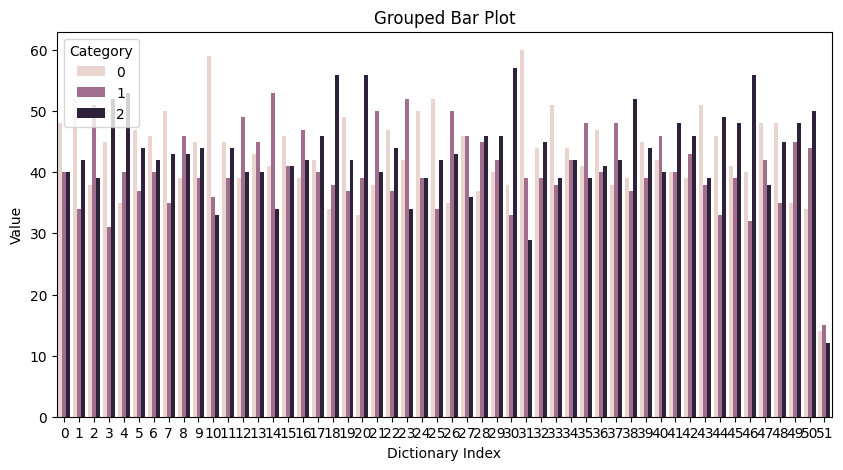

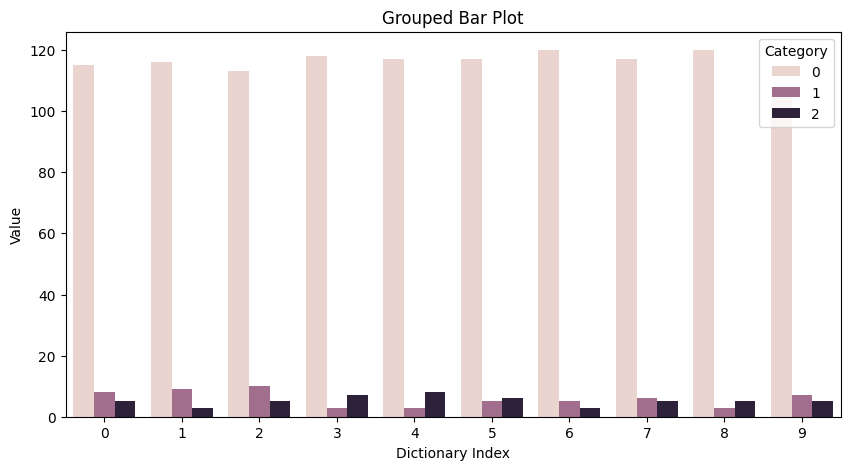

In [22]:
def count_class(loader):
    lst = []
    for x, y in loader:
        cls_count = {}
        
        for label in y:
            label = label.item()
            if label in cls_count:
                cls_count[label] += 1
            else: 
                cls_count[label] = 1
        lst.append(cls_count)

    df = pd.DataFrame(lst).fillna(0)
    
    df_long = df.reset_index().melt(
        id_vars="index",
        var_name="Category",
        value_name="Value"
    )
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_long, x="index", y="Value", hue="Category")
    
    plt.xlabel("Dictionary Index")
    plt.ylabel("Value")
    plt.title("Grouped Bar Plot")
    
    plt.show()

count_class(train_loader)
count_class(test_loader)

In [23]:
shapes = []
for data in train_set:
    if data[0].shape not in shapes:
        shapes.append(data[0].shape)

shapes # Just to insure all the shapes are equal

[torch.Size([3, 40, 141])]

In [24]:
class ModelArchitecture(nn.Module):
    def __init__(
        self, 
        num_channels: int = 3, 
        num_classes: int = 3
    ):
        super(ModelArchitecture, self).__init__()

        # Conv1
        self.conv1 = nn.Conv2d(num_channels, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.shortcut1 = nn.Sequential(
            nn.Conv2d(num_channels, 32, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(32)
        )
        
        # Conv2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) 
        self.shortcut2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64)
        )
        # Conv3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) 
        self.shortcut3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128)
        )
        
        self.pool = nn.MaxPool2d(2, 2) 

        # Fully Connected Network
        self.fc1 = nn.Linear(128*5*17, 32) 
        self.fc2 = nn.Linear(32, num_classes)

        self.dropout = nn.Dropout(p=0.3)  
        self.dropout2d = nn.Dropout2d(p=0.5)

    def forward(self, x):
        res = self.shortcut1(x)
        out = self.bn1(self.conv1(x))
        out += res
        x = self.dropout2d(self.pool(F.relu(out)))   

        res = self.shortcut2(x)
        out = self.bn2(self.conv2(x))
        out += res
        x = self.dropout2d(self.pool(F.relu(out)))

        
        res = self.shortcut3(x)
        out = self.bn3(self.conv3(x))
        out += res
        x = self.dropout2d(self.pool(F.relu(out)))

        x = x.view(x.size(0), -1) 

        # Feed forward network
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [25]:
model = ModelArchitecture(3, 3)
model.to(device)

ModelArchitecture(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

In [26]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 452771


In [27]:
lr = LEARNING_RATE
epoch = EPOCH

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoch, eta_min=1e-5)

In [28]:
def train(model, loader, loss_fn, optimizer, device=None):
    """
    Training function.

    Arg(s):
        model (nn.Module): Model to train.
        loader (DataLoader): Training data loader.
        loss function (nn.Module): A criterion or loss function.
        optimizer (nn.Module): Optimizer.
        device (str): Optional['cpu', 'cuda']
    return:
        (Running Loss, Current Accuracy)
    """
    model.train()

    running_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(loader, desc="Training Batch..."):
        if device:
            x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = loss_fn(logits, y)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y).sum().item()
        total += x.size(0)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    accuracy = correct / total

    return running_loss / total, accuracy

In [29]:
def validate(model, loader, loss_fn, device=None):
    """
    Validation function.

    Arg(s):
        model (nn.Module): Model to train.
        loader (DataLoader): Training data loader.
        loss function (nn.Module): A criterion or loss function.
        device (str): Optional['cpu', 'cuda']
    return:
        (Running Loss, Current Accuracy)
    """
    model.eval()  
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Testing Batch..."):
            if device:
                x, y = x.to(device), y.to(device)
            
            logits = model(x)
            loss = loss_fn(logits, y)

            # Predictions
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == y).sum().item()
            total += x.size(0)

            # Accumulate loss
            running_loss += loss.item() * x.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [30]:
# Store every loss and accuracy
accuracy_history = [[], []]
loss_history = [[], []]

patient = 10
min_val_loss = float('inf')
counter = 0

for i in range(1, epoch + 1):
    training_loss, training_acc = train(model, train_loader, criterion, optimizer, device=device)
    validation_loss, validation_acc = validate(model, test_loader, criterion, device=device)

    scheduler.step(validation_loss)
    
    if validation_loss < min_val_loss:
        min_val_loss = validation_loss
        counter = 0
    else:
        counter += 1
        print(f"Loss not improving: {counter}/{patient}")
        
        if counter >= patient:
            print("Early stopping triggered")
            break

    print(f"Epoch ({i}/{epoch}): train_loss = {training_loss:.4f}, val_loss = {validation_loss:.4f}, train_acc = {training_acc:.4f}, val_acc = {validation_acc:.4f}")

    accuracy_history[0].append(training_acc)
    accuracy_history[1].append(validation_acc)

    loss_history[0].append(training_loss)
    loss_history[1].append(validation_loss)

Testing Batch...: 100%|██████████| 10/10 [00:00<00:00, 48.25it/s]
/tmp/ipykernel_57/2155545558.py:13: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(validation_loss)


Epoch (1/100): train_loss = 1.0769, val_loss = 0.8353, train_acc = 0.4141, val_acc = 0.8829


Testing Batch...: 100%|██████████| 10/10 [00:00<00:00, 50.26it/s]


Epoch (2/100): train_loss = 0.9848, val_loss = 0.7049, train_acc = 0.5051, val_acc = 0.8420


Testing Batch...: 100%|██████████| 10/10 [00:00<00:00, 50.45it/s]


...

Loss not improving: 8/10
Epoch (96/100): train_loss = 0.4624, val_loss = 0.4100, train_acc = 0.9403, val_acc = 0.9481


Testing Batch...: 100%|██████████| 10/10 [00:00<00:00, 49.15it/s]


Loss not improving: 9/10
Epoch (97/100): train_loss = 0.4560, val_loss = 0.4139, train_acc = 0.9431, val_acc = 0.9450


Testing Batch...: 100%|██████████| 10/10 [00:00<00:00, 50.95it/s]

Loss not improving: 10/10
Early stopping triggered


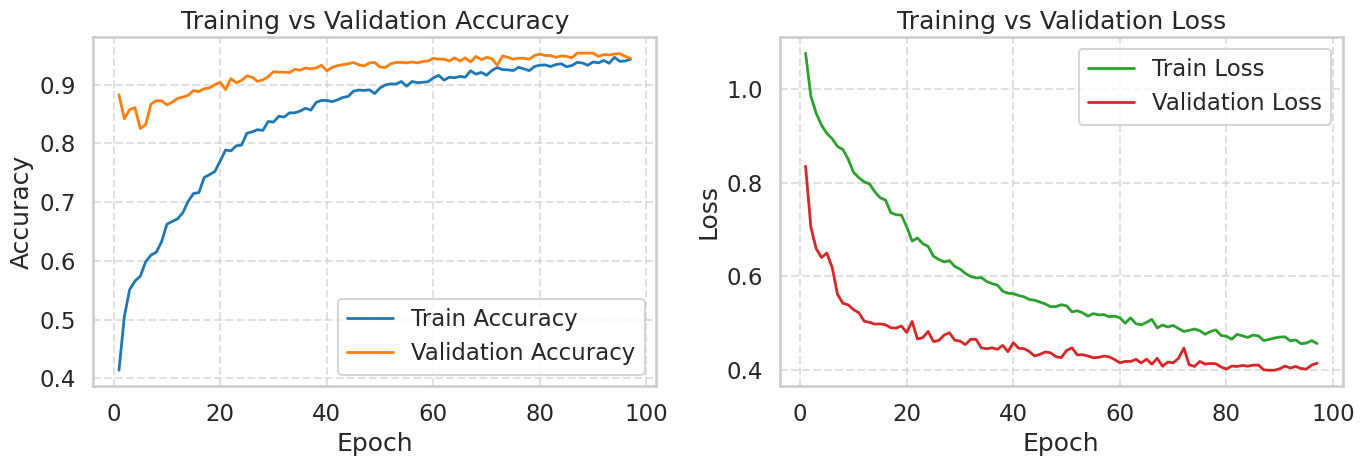

In [31]:
# Apply seaborn styling
sns.set_style("whitegrid")
sns.set_context("talk")

epochs = range(1, len(loss_history[0]) + 1)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axs[0].plot(epochs, accuracy_history[0], label='Train Accuracy', color='tab:blue', linewidth=2)
axs[0].plot(epochs, accuracy_history[1], label='Validation Accuracy', color='tab:orange', linewidth=2)

axs[0].set_title('Training vs Validation Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# Loss Plot 
axs[1].plot(epochs, loss_history[0], label='Train Loss', color='tab:green', linewidth=2)
axs[1].plot(epochs, loss_history[1], label='Validation Loss', color='tab:red', linewidth=2)

axs[1].set_title('Training vs Validation Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [32]:
total = len(test_set)
corr = 0
y_pred = []
y_true = []
with torch.no_grad():
    for tensor, label in tqdm(test_set, desc="Testing..."):
        logits = model(tensor.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).item()
        y_pred.append(pred)
        y_true.append(label)
        if pred == label:
            corr += 1

Testing...: 100%|██████████| 1272/1272 [00:01<00:00, 877.24it/s]


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1161
           1       0.80      0.83      0.82        59
           2       0.54      0.94      0.69        52

    accuracy                           0.95      1272
   macro avg       0.78      0.91      0.83      1272
weighted avg       0.96      0.95      0.96      1272



<Axes: >

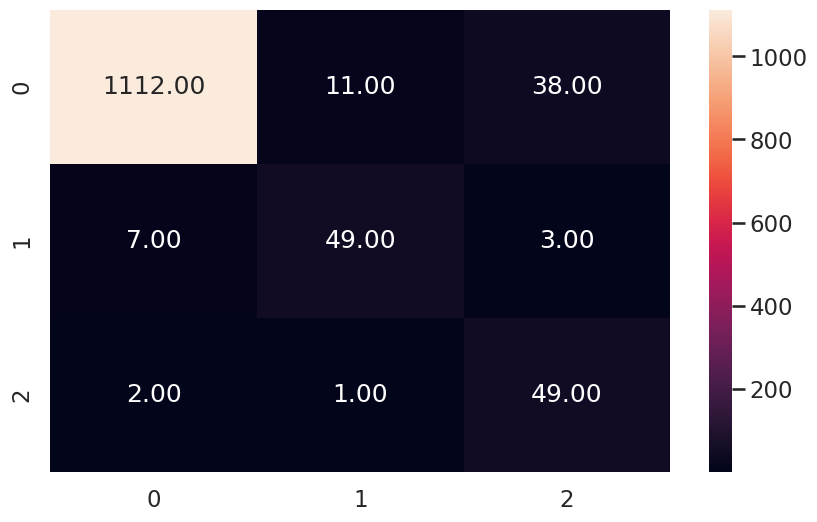

In [34]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt=".2f")

In [ ]:
torch.save(model.state_dict(), 'model.pth')